# B.6 -SpatialPeeler benchmark evaluation: 3×3×3 parameter grid

Runs SpatialPeeler on all 27 benchmark conditions generated by `B.5.benchmark_nmfGenes_grid.ipynb`.

**Conditions:** 3 perturb_fracs × 3 lambdas × 3 top_genes = 27 case files in `generated_benchmark_data_final/`.

**Metric:** spot-based in-circle AUROC — for each condition, the top factor chosen by  
SpatialPeeler (highest positive logistic regression coefficient) is evaluated against  
the ground-truth `obs['in_circle']` column on case beads only.

In [1]:
import sys
import warnings
from itertools import product
from pathlib import Path
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import roc_auc_score

warnings.simplefilter('ignore', category=ConvergenceWarning)
sc.settings.verbosity = 0

ROOT    = Path('/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler')
sys.path.insert(0, str(ROOT))

RAND_SEED  = 28
N_FACTORS  = 15
np.random.seed(RAND_SEED)

DATA_DIR  = ROOT / 'benchmark' / 'generated_benchmark_data'
FINAL_DIR = ROOT / 'benchmark' / 'generated_benchmark_data_final'

In [2]:
print('ROOT:', ROOT)
print('Case files:', len(list(FINAL_DIR.glob('*.h5ad'))))

ROOT: /lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler
Case files: 64


#### 1. Load control (shared across all conditions)

In [3]:
adata_ctrl = ad.read_h5ad(DATA_DIR / 'adata06_top.h5ad')
adata_ctrl.obs['sample_id'] = 'ctrl'
adata_ctrl.obs['status']    = 0
adata_ctrl.obs['Condition'] = 'Control'
if 'in_circle' not in adata_ctrl.obs.columns:
    adata_ctrl.obs['in_circle'] = False
adata_ctrl.obs['in_circle'] = adata_ctrl.obs['in_circle'].astype(bool)

print('Control:', adata_ctrl.shape)

Control: (34392, 26548)


In [4]:
print(adata_ctrl)
adata_ctrl.obs

AnnData object with n_obs × n_vars = 34392 × 26548
    obs: 'nCount_Spatial', 'nFeature_Spatial', 'PuckID', 'Raw_Slideseq_X', 'Raw_Slideseq_Y', 'Puck_Depth', 'nCount_Spatial.1', 'nFeature_Spatial.1', 'CCF_X', 'CCF_Y', 'CCF_Z', 'TopStruct', 'DeepCCF', 'CCF_acronym', 'CCF_ID', 'CCF_Name', 'CCF_LeftRight', 'IsOutsideCCF', 'Correponding_DissectateSegName', 'Correponding_DissectateSegID', 'NisslTiffX', 'NisslTiffY', 'BeadBarcode', '.id', 'orig.ident', 'sample_id', 'status', 'Condition', 'in_circle'
    var: 'gene_id', 'features'


,nCount_Spatial,nFeature_Spatial,PuckID,Raw_Slideseq_X,Raw_Slideseq_Y,Puck_Depth,nCount_Spatial.1,nFeature_Spatial.1,CCF_X,CCF_Y,...,Correponding_DissectateSegID,NisslTiffX,NisslTiffY,BeadBarcode,.id,orig.ident,sample_id,status,Condition,in_circle
MBASSdd13_AACAGAACCATGCC-1,4227.0,2351,Puck_210218_07,3155.4,1829.6,MBASS_dd13,4227.0,2351,104,158,...,0,1159,977,MBASSdd13_AACAGAACCATGCC-1,MBASS_dd13,5,ctrl,0,Control,False
MBASSdd13_GTGGTTTTTTTTTT-1,3469.0,1971,Puck_210218_07,3223.9,2087.8,MBASS_dd13,3469.0,1971,104,154,...,0,1184,1120,MBASSdd13_GTGGTTTTTTTTTT-1,MBASS_dd13,5,ctrl,0,Control,False
MBASSdd13_AGTCACTCATACTT-1,3372.0,1954,Puck_210218_07,4406.4,1239.5,MBASS_dd13,3372.0,1954,108,74,...,0,1846,758,MBASSdd13_AGTCACTCATACTT-1,MBASS_dd13,5,ctrl,0,Control,False
MBASSdd13_AGCATTAATGTCTT-1,3333.0,1963,Puck_210218_07,3597.4,2016.8,MBASS_dd13,3333.0,1963,105,127,...,0,1399,1095,MBASSdd13_AGCATTAATGTCTT-1,MBASS_dd13,5,ctrl,0,Control,False
MBASSdd13_NCCATAGCCCTATT-1,3330.0,1794,Puck_210218_07,3447.7,1422.3,MBASS_dd13,3330.0,1794,105,136,...,0,1333,789,MBASSdd13_NCCATAGCCCTATT-1,MBASS_dd13,5,ctrl,0,Control,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MBASSdd13_ATCAACGGGGAACA-1,10.0,7,Puck_210218_07,4184.8,1087.8,MBASS_dd13,10.0,7,107,87,...,0,1733,667,MBASSdd13_ATCAACGGGGAACA-1,MBASS_dd13,5,ctrl,0,Control,False
MBASSdd13_CCATGACTGCTCCA-1,10.0,10,Puck_210218_07,2616.1,1627.0,MBASS_dd13,10.0,10,102,198,...,0,876,863,MBASSdd13_CCATGACTGCTCCA-1,MBASS_dd13,5,ctrl,0,Control,False
MBASSdd13_AGCTTAAATTTTTA-1,10.0,8,Puck_210218_07,3373.2,1842.5,MBASS_dd13,10.0,8,104,142,...,0,1280,995,MBASSdd13_AGCTTAAATTTTTA-1,MBASS_dd13,5,ctrl,0,Control,False
MBASSdd13_AGTACCCCCCGTAA-1,10.0,10,Puck_210218_07,2190.7,1446.1,MBASS_dd13,10.0,10,100,225,...,0,643,760,MBASSdd13_AGTACCCCCCGTAA-1,MBASS_dd13,5,ctrl,0,Control,False


#### 2. Define the parameter grid

In [5]:
#PERTURB_FRACS  = [0.30, 0.50, 0.70]
#FIXED_LAMS     = [0.5,  0.3,  0.15]
#TOP_GENES_LIST = [1, 5, 10]

PERTURB_FRACS       = [0.30, 0.50, 0.70, 1.0]
FIXED_LAMS          = [3, 0.5,  0.3,  0.15]
TOP_GENES_LIST      = [1, 2, 5, 10]

grid = list(product(PERTURB_FRACS, FIXED_LAMS, TOP_GENES_LIST))
print(f'{len(grid)} conditions')

64 conditions


#### 3. Helper functions

In [6]:
def preprocess(adata_ctrl, adata_case, force_genes=None):
    """Concat, filter, normalise, HVG, scale. Returns combined adata.
    force_genes: set of gene symbols to retain regardless of HVG status.
    """
    adata = ad.concat(
        [adata_ctrl, adata_case],
        join='inner', merge='first',
        label='sample_id', keys=['ctrl', 'case'],
        index_unique='-'
    )
    for col in ['status', 'Condition', 'in_circle']:
        adata.obs[col] = np.concatenate([
            adata_ctrl.obs[col].values,
            adata_case.obs[col].values
        ])
    adata.obs['status']    = adata.obs['status'].astype(int)
    adata.obs['in_circle'] = adata.obs['in_circle'].astype(bool)

    adata.layers['counts'] = adata.X.copy()

    # gene filter
    min_cells = max(1, adata.n_obs // 500)
    n_expr    = np.array((adata.X > 0).sum(axis=0)).flatten()
    adata     = adata[:, n_expr >= min_cells].copy()

    # lognorm + HVG (lognorm only for HVG selection - nmf is run on unit-variance scaled counts)
    adata.layers['lognorm'] = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4, layer='lognorm')
    sc.pp.log1p(adata, layer='lognorm')
    sc.pp.highly_variable_genes(
        adata, n_top_genes=2000,
        batch_key='sample_id', flavor='seurat',
        layer='lognorm', subset=False
    )

    # force perturbed genes into HVG set so they are always available for correlation
    if force_genes is not None:
        symbols = (adata.var['features'].values
                   if 'features' in adata.var.columns
                   else adata.var_names.values)
        is_forced = np.isin(symbols, list(force_genes))
        n_forced  = is_forced.sum()
        adata.var['highly_variable'] = adata.var['highly_variable'] | is_forced
        print(f'  forced {n_forced}/{len(force_genes)} genes into HVG set', end=' ')

    adata = adata[:, adata.var['highly_variable']].copy()
    sc.pp.scale(adata, zero_center=False)
    return adata


def run_nmf(adata, n_factors=N_FACTORS, rand_seed=RAND_SEED):
    X = adata.X
    if sp.issparse(X):
        X = X.toarray()
    X = X.astype(np.float32)
    model = NMF(n_components=n_factors, init='nndsvda',
                random_state=rand_seed, max_iter=1000, solver='cd')
    W = model.fit_transform(X)
    adata.obsm['X_nmf'] = W
    return W


def run_spatialpeeler(adata, n_factors=N_FACTORS):
    """Logistic regression for each factor. Returns list of result dicts."""
    X  = adata.obsm['X_nmf']
    y  = adata.obs['status'].values
    results = []
    for i in range(n_factors):
        Xi    = X[:, i].reshape(-1, 1)
        X_int = sm.add_constant(Xi)
        try:
            fit = sm.Logit(y, X_int).fit(disp=False)
            p_hat = fit.predict(X_int)
            coef  = float(fit.params[1])
            pval  = float(fit.pvalues[1])
        except Exception:
            p_hat = np.full(len(y), np.nan)
            coef  = 0.0
            pval  = 1.0
        results.append({'factor_index': i, 'coef': coef, 'pval': pval, 'p_hat': p_hat})
    return results


def incircle_auroc(results, adata):
    """For each factor, compute AUROC of p_hat vs in_circle on case beads."""
    case_mask = adata.obs['status'].values == 1
    gt        = adata.obs['in_circle'].values[case_mask].astype(int)
    aucs = {}
    for r in results:
        ph_case = r['p_hat'][case_mask]
        if np.isnan(ph_case).all() or len(np.unique(gt)) < 2:
            aucs[r['factor_index']] = np.nan
        else:
            try:
                aucs[r['factor_index']] = roc_auc_score(gt, ph_case)
            except Exception:
                aucs[r['factor_index']] = np.nan
    return aucs


print('Helper functions ready.')

Helper functions ready.


In [7]:
def phat_gene_corr(adata, p_hat, case_only=True):
    """Vectorised Pearson correlation between p_hat and lognorm expression of each gene.
    Uses case beads only by default (where the circle signal lives).
    """
    mask = (adata.obs['status'].values == 1) if case_only else np.ones(adata.n_obs, bool)
    X  = adata.layers['lognorm'][mask, :]
    if sp.issparse(X):
        X = X.toarray()
    pv = p_hat[mask] # phat for case beads only (or all beads if case_only=False)

    Xc  = X - X.mean(axis=0) # centre gene expression
    pvc = pv - pv.mean()      # centre p_hat
    dX  = np.sqrt((Xc ** 2).sum(axis=0))  # l2 norm of each gene's centred expression
    dp  = np.sqrt((pvc ** 2).sum()) 

    with np.errstate(divide='ignore', invalid='ignore'):
        corr = np.where( ## pearson calculation vectorised for all genes at once
            (dX > 0) & (dp > 0), # handling zero-variance genes or p_hat
            (Xc.T @ pvc) / (dX * dp), # Xc is matrix - calculate correlations for all genes at once
            np.nan
        )

    genes = (adata.var['features'].values
             if 'features' in adata.var.columns
             else adata.var_names.values)
    return pd.DataFrame({'gene': genes, 'correlation': corr}).sort_values(
        'correlation', ascending=False, ignore_index=True
    )


def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    return len(a & b) / len(a | b) if (a | b) else 0.0


# Ground-truth perturbed gene sets for each top_genes value
nmf_genes_by_tg = {}
for tg in TOP_GENES_LIST:
    csv_path = FINAL_DIR / f'nmf_genes_top{tg}_per_factor.csv'
    nmf_genes_by_tg[tg] = set(pd.read_csv(csv_path)['gene'].unique())
    print(f'top_genes={tg:>2}: {len(nmf_genes_by_tg[tg])} unique perturbed genes')

top_genes= 1: 15 unique perturbed genes
top_genes= 2: 30 unique perturbed genes
top_genes= 5: 73 unique perturbed genes
top_genes=10: 138 unique perturbed genes


#### Run the pipeline on one condition as a test

In [11]:
N_CONDITIONS = len(grid)  # set to len(grid) to run all 27

rows = []
pf = 1
lam = 3
tg = 5
tag  = f'frac{pf:.0%}_lam{lam}_top{tg}genes'
path = FINAL_DIR / f'adata06_bot_case_nmfGenes_{tag}.h5ad'
print(path)

adata_case = ad.read_h5ad(path)
adata_case.obs['sample_id'] = 'case'
adata_case.obs['status']    = 1
adata_case.obs['Condition'] = 'Case'
adata_case.obs['in_circle'] = adata_case.obs['in_circle'].astype(bool)

print(adata_case.shape)
print(adata_case)


/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/benchmark/generated_benchmark_data_final/adata06_bot_case_nmfGenes_frac100%_lam3_top5genes.h5ad
(45408, 26548)
AnnData object with n_obs × n_vars = 45408 × 26548
    obs: 'nCount_Spatial', 'nFeature_Spatial', 'PuckID', 'Raw_Slideseq_X', 'Raw_Slideseq_Y', 'Puck_Depth', 'nCount_Spatial.1', 'nFeature_Spatial.1', 'CCF_X', 'CCF_Y', 'CCF_Z', 'TopStruct', 'DeepCCF', 'CCF_acronym', 'CCF_ID', 'CCF_Name', 'CCF_LeftRight', 'IsOutsideCCF', 'Correponding_DissectateSegName', 'Correponding_DissectateSegID', 'NisslTiffX', 'NisslTiffY', 'BeadBarcode', '.id', 'orig.ident', 'in_circle', 'sample_id', 'status', 'Condition'
    var: 'gene_id', 'features'


In [12]:
n_in_circle = adata_case.obs['in_circle'].sum()
print(n_in_circle, 'in-circle beads in case sample')
gt_genes    = nmf_genes_by_tg[tg]
print(gt_genes)
n_gt = len(gt_genes)

adata = preprocess(adata_ctrl, adata_case, force_genes=gt_genes)

6394 in-circle beads in case sample
{'Erbb3', 'Gm27167', 'Gm16168', 'Stx11', 'Gucy1b2', 'Apod', 'Mobp', 'Gm26850', 'Gm36831', 'Gm37311', 'Frrs1l', 'Pyurf', '6330403K07Rik', 'Spryd4', 'Lrrc36', 'Jmjd1c', 'Rnase4', 'Hsf5', 'Car9', 'Trdmt1', 'Gabra6', 'Rnf122', 'Pik3c2b', 'Gm3764', 'Gm26716', 'Sim1', 'Tex30', 'Phactr1', 'Gm37954', 'Plp1', 'Pla2g7', 'Prss45', 'Gstm1', 'Tmem132d', '9630013A20Rik', 'Crtc3', 'Prdx6', 'Haus7', 'Ntn3', 'Ppp2r2c', 'Ywhab', 'Mrap', 'Styk1', 'Syn2', 'Fat3', 'Atp10b', 'Ikzf1', 'Gm13775', 'Mbp', 'Ptgds', 'Mon1b', 'Kpna7', 'Gm48877', 'Mep1a', 'Med9', 'Gm11110', 'Slco2b1', 'Traf3ip2', 'Ptprn2', 'Gm43018', 'Gm38300', 'Chmp1b', 'Kcnh7', 'Prex2', 'Mknk1', 'Lrrc17', 'Nudt6', 'Zxdb', 'Ctss', 'Olfml3', 'Sycp3', 'Gm17215', 'Arhgef16'}
  forced 73/73 genes into HVG set 

In [13]:
run_nmf(adata)
results = run_spatialpeeler(adata)

In [14]:
aucs    = incircle_auroc(results, adata)
aucs

{0: 0.5043650908885896,
 1: 1.0,
 2: 0.5594737921128993,
 3: 0.49108466096215725,
 4: 0.5022278100276604,
 5: 0.5527640928172541,
 6: 0.502754691541878,
 7: 0.5289888258073235,
 8: 0.5035775396524005,
 9: 0.45786775266176116,
 10: 0.5331083278190569,
 11: 0.513260534595675,
 12: 0.5052451335652165,
 13: 0.5046726126513073,
 14: 0.5356367164877606}

In [15]:
top_r    = max(results, key=lambda r: r['coef'])
top_fi   = top_r['factor_index']
top_auc  = aucs[top_fi]
best_auc = max(aucs.values())

print(f'Best result: {top_r}')
print(f'Best AUROC: {best_auc:.4f} (factor {top_fi})')
print(f'AUROC of the best factor: {top_auc:.4f}')
print(f'Best AUC over all factors: {best_auc:.4f}')


Best result: {'factor_index': 1, 'coef': 24.18646252606713, 'pval': 1.6563960875484975e-22, 'p_hat': array([0.57847132, 0.52415203, 0.52415203, ..., 0.52415203, 0.52415203,
       0.52415203])}
Best AUROC: 1.0000 (factor 1)
AUROC of the best factor: 1.0000
Best AUC over all factors: 1.0000


In [16]:
# correlation-based gene recovery
corr_df       = phat_gene_corr(adata, top_r['p_hat'], case_only=True)

In [17]:
gt_in_hvg     = gt_genes & set(corr_df['gene'].dropna())
print(len(gt_genes))
print(len(gt_in_hvg))

recovered_all = set(corr_df.head(n_gt)['gene'].values)
recovered_hvg = set(corr_df.head(len(gt_in_hvg))['gene'].values)
j_all = jaccard(recovered_all, gt_genes)
j_hvg = jaccard(recovered_hvg, gt_in_hvg)

print(f'top_factor=F{top_fi+1}  top_auc={top_auc:.3f}  '
        f'j_corr={j_all:.3f}  gt_in_hvg={len(gt_in_hvg)}/{n_gt}')


73
73
top_factor=F2  top_auc=1.000  j_corr=1.000  gt_in_hvg=73/73


#### 4. Run all 27 conditions

For each condition:
1. Load case h5ad
2. Preprocess (concat with ctrl, HVG, scale)
3. NMF (k=15)
4. SpatialPeeler logistic regression
5. Pick top factor (highest positive coefficient)
6. Record in-circle AUROC and correlation-based gene recovery (Jaccard)
7. KMeans cluster case beads on p_hat → Wilcoxon DE → DE-based gene recovery (Jaccard)

In [19]:
N_CONDITIONS = len(grid)  # set to len(grid) to run all 27 (v1) 64(v2)

rows = []

for i, (pf, lam, tg) in enumerate(grid[:N_CONDITIONS]):
    tag  = f'frac{pf:.0%}_lam{lam}_top{tg}genes'
    path = FINAL_DIR / f'adata06_bot_case_nmfGenes_{tag}.h5ad'

    print(f'[{i+1:02d}/{N_CONDITIONS}] {tag} ...', end=' ', flush=True)

    adata_case = ad.read_h5ad(path)
    adata_case.obs['sample_id'] = 'case'
    adata_case.obs['status']    = 1
    adata_case.obs['Condition'] = 'Case'
    adata_case.obs['in_circle'] = adata_case.obs['in_circle'].astype(bool)

    n_in_circle = adata_case.obs['in_circle'].sum()
    gt_genes    = nmf_genes_by_tg[tg]
    n_gt        = len(gt_genes)

    adata = preprocess(adata_ctrl, adata_case, force_genes=gt_genes)
    run_nmf(adata)
    results = run_spatialpeeler(adata)
    aucs    = incircle_auroc(results, adata)

    top_r    = max(results, key=lambda r: r['coef'])
    top_fi   = top_r['factor_index']
    top_auc  = aucs[top_fi]
    best_auc = max(aucs.values())

    # ── correlation-based gene recovery ──────────────────────────────────
    corr_df       = phat_gene_corr(adata, top_r['p_hat'], case_only=True)
    gt_in_hvg     = gt_genes & set(corr_df['gene'].dropna())
    recovered_all = set(corr_df.head(n_gt)['gene'].values)
    recovered_hvg = set(corr_df.head(len(gt_in_hvg))['gene'].values)
    j_all = jaccard(recovered_all, gt_genes)
    j_hvg = jaccard(recovered_hvg, gt_in_hvg)

    # ── DE-based gene recovery ────────────────────────────────────────────
    case_mask  = adata.obs['status'].values == 1
    ctrl_mask  = ~case_mask
    p_hat_case = top_r['p_hat'][case_mask]

    km      = KMeans(n_clusters=2, random_state=RAND_SEED, n_init='auto')
    km.fit(p_hat_case.reshape(-1, 1))
    centers = km.cluster_centers_.ravel()
    order   = np.argsort(centers)
    remap   = {order[0]: 0, order[1]: 1}
    case_km = np.vectorize(remap.get)(km.labels_)

    threshold      = centers.mean()
    cluster_labels = np.empty(adata.n_obs, dtype=object)
    cluster_labels[case_mask] = np.where(case_km == 1, 'case_1', 'case_0')
    cluster_labels[ctrl_mask] = np.where(
        top_r['p_hat'][ctrl_mask] >= threshold, 'control_1', 'control_0'
    )

    grp_mask = cluster_labels == 'case_1'
    ref_mask = cluster_labels == 'control_0'
    j_de           = np.nan
    n_de_recovered = 0

    if grp_mask.sum() >= 5 and ref_mask.sum() >= 5:
        adata_de = adata[grp_mask | ref_mask].copy()
        adata_de.obs['_grp'] = pd.Categorical(
            np.where(cluster_labels[grp_mask | ref_mask] == 'case_1', 'case_1', 'control_0'),
            categories=['control_0', 'case_1']
        )
        sc.tl.rank_genes_groups(
            adata_de, groupby='_grp', groups=['case_1'], reference='control_0',
            method='wilcoxon', corr_method='benjamini-hochberg',
            use_raw=False, layer='lognorm', n_genes=adata_de.n_vars
        )
        de_result = sc.get.rank_genes_groups_df(adata_de, group='case_1')

        var_to_symbol = dict(zip(
            adata.var_names,
            adata.var['features'].values if 'features' in adata.var.columns
            else adata.var_names.values
        ))
        de_result['gene_symbol'] = de_result['names'].map(var_to_symbol)

        top_de = set(
            de_result.sort_values('logfoldchanges', ascending=False)
            .head(n_gt)['gene_symbol'].values
        )
        j_de           = jaccard(top_de, gt_genes)
        n_de_recovered = len(top_de & gt_genes)

    print(f'top_factor=F{top_fi+1}  top_auc={top_auc:.3f}  '
          f'j_corr={j_all:.3f}  j_de={j_de:.3f}  '
          f'case_1={grp_mask.sum():,}  gt_in_hvg={len(gt_in_hvg)}/{n_gt}')

    row = {
        'perturb_frac':     pf,
        'fixed_lam':        lam,
        'top_genes':        tg,
        'tag':              tag,
        'n_in_circle':      int(n_in_circle),
        'top_factor':       top_fi + 1,
        'top_coef':         top_r['coef'],
        'top_pval':         top_r['pval'],
        'top_auc':          top_auc,
        'best_auc':         best_auc,
        'gene_jaccard_all': j_all,
        'gene_jaccard_hvg': j_hvg,
        'gene_jaccard_de':  j_de,
        'n_gt_genes':       n_gt,
        'n_gt_in_hvg':      len(gt_in_hvg),
        'n_recovered_all':  len(recovered_all & gt_genes),
        'n_recovered_hvg':  len(recovered_hvg & gt_in_hvg),
        'n_de_recovered':   n_de_recovered,
        'n_case_1':         int(grp_mask.sum()),
        'n_control_0':      int(ref_mask.sum()),
    }
    for fi, auc in aucs.items():
        row[f'auc_f{fi+1}'] = auc
    rows.append(row)

results_df = pd.DataFrame(rows)
print('\nDone.')
print(results_df[['tag', 'top_factor', 'top_auc',
                   'gene_jaccard_all', 'gene_jaccard_de',
                   'n_gt_genes', 'n_recovered_all', 'n_de_recovered']].to_string(index=False))

[01/64] frac30%_lam3_top1genes ...   forced 15/15 genes into HVG set top_factor=F2  top_auc=0.662  j_corr=1.000  j_de=1.000  case_1=1,930  gt_in_hvg=15/15
[02/64] frac30%_lam3_top2genes ...   forced 30/30 genes into HVG set top_factor=F2  top_auc=0.659  j_corr=1.000  j_de=1.000  case_1=1,930  gt_in_hvg=30/30
[03/64] frac30%_lam3_top5genes ...   forced 73/73 genes into HVG set top_factor=F2  top_auc=0.657  j_corr=1.000  j_de=1.000  case_1=1,948  gt_in_hvg=73/73
[04/64] frac30%_lam3_top10genes ...   forced 138/138 genes into HVG set top_factor=F1  top_auc=0.665  j_corr=1.000  j_de=1.000  case_1=1,937  gt_in_hvg=138/138
[05/64] frac30%_lam0.5_top1genes ...   forced 15/15 genes into HVG set top_factor=F7  top_auc=0.666  j_corr=1.000  j_de=1.000  case_1=1,992  gt_in_hvg=15/15
[06/64] frac30%_lam0.5_top2genes ...   forced 30/30 genes into HVG set top_factor=F3  top_auc=0.657  j_corr=1.000  j_de=1.000  case_1=1,945  gt_in_hvg=30/30
[07/64] frac30%_lam0.5_top5genes ...   forced 73/73 genes int

KeyboardInterrupt: 

In [21]:

results_df = pd.DataFrame(rows)
print('\nDone.')
print(results_df[['tag', 'top_factor', 'top_auc',
                   'gene_jaccard_all', 'gene_jaccard_de',
                   'n_gt_genes', 'n_recovered_all', 'n_de_recovered']].to_string(index=False))


Done.
                     tag  top_factor  top_auc  gene_jaccard_all  gene_jaccard_de  n_gt_genes  n_recovered_all  n_de_recovered
  frac30%_lam3_top1genes           2 0.661883               1.0              1.0          15               15              15
  frac30%_lam3_top2genes           2 0.658671               1.0              1.0          30               30              30
  frac30%_lam3_top5genes           2 0.656984               1.0              1.0          73               73              73
 frac30%_lam3_top10genes           1 0.664648               1.0              1.0         138              138             138
frac30%_lam0.5_top1genes           7 0.665915               1.0              1.0          15               15              15
frac30%_lam0.5_top2genes           3 0.657265               1.0              1.0          30               30              30


In [22]:
results_df.head()

,perturb_frac,fixed_lam,top_genes,tag,n_in_circle,top_factor,top_coef,top_pval,top_auc,best_auc,...,auc_f6,auc_f7,auc_f8,auc_f9,auc_f10,auc_f11,auc_f12,auc_f13,auc_f14,auc_f15
0,0.3,3.0,1,frac30%_lam3_top1genes,6394,2,10.733277,8.864872e-44,0.661883,0.661883,...,0.529864,0.507098,0.508780,0.553726,0.466604,0.482697,0.526218,0.517968,0.506659,0.518094
1,0.3,3.0,2,frac30%_lam3_top2genes,6394,2,11.335210,5.843767e-19,0.658671,0.658671,...,0.531897,0.510849,0.505730,0.555157,0.464234,0.483889,0.520152,0.539875,0.503029,0.513180
2,0.3,3.0,5,frac30%_lam3_top5genes,6394,2,18.851216,1.307975e-24,0.656984,0.656984,...,0.532062,0.554947,0.505916,0.508216,0.463223,0.483740,0.540707,0.517879,0.501094,0.516729
3,0.3,3.0,10,frac30%_lam3_top10genes,6394,1,27.962931,2.120939e-24,0.664648,0.664648,...,0.530385,0.558838,0.513484,0.509212,0.461998,0.483955,0.506287,0.518104,0.513384,0.509781
4,0.3,0.5,1,frac30%_lam0.5_top1genes,6394,7,13.050664,5.997493e-127,0.665915,0.665915,...,0.514780,0.665915,0.523734,0.542070,0.476561,0.512584,0.536114,0.525592,0.496667,0.530794


In [ ]:
SAVE_PATH = ROOT / 'benchmark' / 'benchmark_results_grid_v5_64parameters.csv'
results_df.to_csv(SAVE_PATH, index=False)
print(f'Saved {len(results_df)} rows → {SAVE_PATH}')

In [ ]:
### read csv results
#results_df = pd.read_csv(ROOT / 'benchmark' / 'benchmark_results_grid_v3.csv')

#### 4.5 DE-based gene recovery (now part of main loop above)

DE evaluation is computed inside the main 27-condition loop: KMeans (k=2) on case bead p_hat splits beads into `case_1` (high p_hat) / `case_0` (low p_hat), then Wilcoxon DE between `case_1` and `control_0`. Top-N upregulated DE genes (N = number of perturbed genes) are compared against the ground-truth set via Jaccard index. Results are stored in `gene_jaccard_de` and `n_de_recovered` columns of `results_df`.

In [ ]:
# DE-based gene recovery has been merged into the main grid loop above (cell aa000010).
# gene_jaccard_de, n_de_recovered, n_case_1, n_control_0 are now columns in results_df.

#### 5. Results summary

In [106]:
print('top_auc (SpatialPeeler top factor)')
print(results_df.groupby(['perturb_frac', 'fixed_lam', 'top_genes'])['top_auc']
      .mean().unstack('top_genes').round(3).to_string())
print()
print('best_auc (oracle: best across all factors)')
print(results_df.groupby(['perturb_frac', 'fixed_lam', 'top_genes'])['best_auc']
      .mean().unstack('top_genes').round(3).to_string())

top_auc (SpatialPeeler top factor)
top_genes                  1      5      10
perturb_frac fixed_lam                     
0.3          0.15       0.566  0.659  0.663
             0.30       0.659  0.659  0.663
             0.50       0.666  0.657  0.663
0.5          0.15       0.574  0.760  0.760
             0.30       0.758  0.758  0.761
             0.50       0.765  0.758  0.760
0.7          0.15       0.578  0.855  0.855
             0.30       0.849  0.854  0.854
             0.50       0.856  0.853  0.855

best_auc (oracle: best across all factors)
top_genes                  1      5      10
perturb_frac fixed_lam                     
0.3          0.15       0.568  0.659  0.663
             0.30       0.659  0.659  0.663
             0.50       0.666  0.657  0.663
0.5          0.15       0.621  0.760  0.760
             0.30       0.758  0.758  0.761
             0.50       0.765  0.758  0.760
0.7          0.15       0.663  0.855  0.855
             0.30       0.849  0.854  0.8

#### 6. Visualise: in-circle AUROC heatmaps across the parameter grid

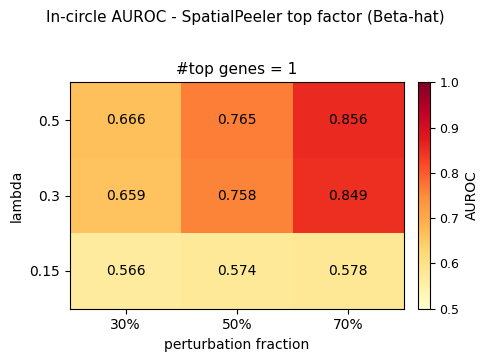

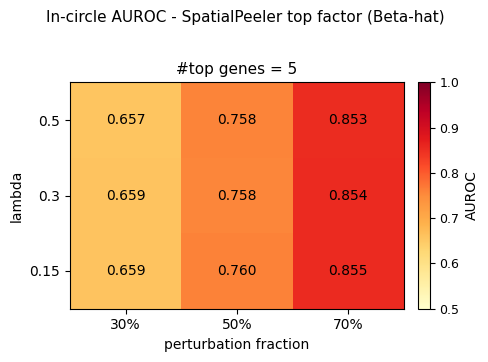

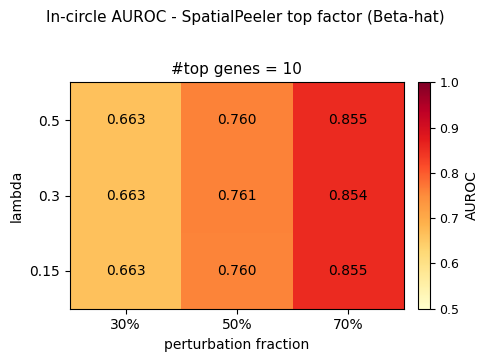

In [105]:
vmin, vmax = 0.5, 1.0

for tg in TOP_GENES_LIST:
    sub = results_df[results_df['top_genes'] == tg]
    mat = sub.pivot(index='fixed_lam', columns='perturb_frac', values='top_auc')
    mat = mat.sort_index(ascending=False)

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ## set colorbar limits to same range for all plots from 0.5 to 1.0
    im = ax.imshow(mat.values, cmap='YlOrRd', vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels([f'{c:.0%}' for c in mat.columns], fontsize=10)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([str(r) for r in mat.index], fontsize=10)
    ax.set_xlabel('perturbation fraction', fontsize=10)
    ax.set_ylabel('lambda', fontsize=10)
    ax.set_title(f'#top genes = {tg}', fontsize=11)

    for r_i, row in enumerate(mat.values):
        for c_i, val in enumerate(row):
            ax.text(c_i, r_i, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, color='black')

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('AUROC', fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    fig.suptitle('In-circle AUROC - SpatialPeeler top factor (Beta-hat)', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

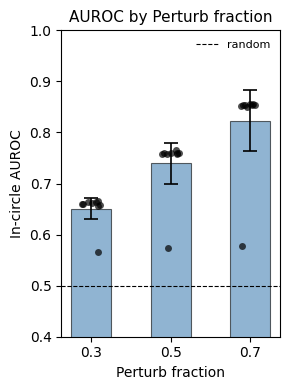

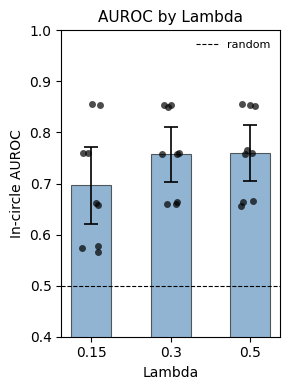

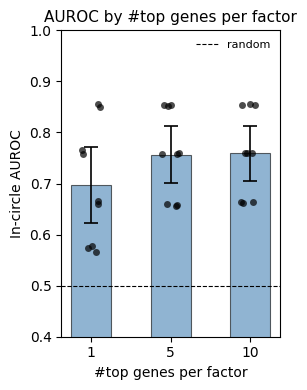

In [104]:

for col, label in [
    ('perturb_frac', 'Perturb fraction'),
    ('fixed_lam',    'Lambda'),
    ('top_genes',    '#top genes per factor'),
]:
    groups = sorted(results_df[col].unique())
    x_pos  = np.arange(len(groups))

    means, cis = [], []
    for grp in groups:
        vals = results_df.loc[results_df[col] == grp, 'top_auc'].values
        means.append(vals.mean())
        cis.append(stats.sem(vals) * 1.96)  # 95% CI half-width


    fig, ax = plt.subplots(figsize=(3, 4))
    ### add edge color as black with linewidth 0.8 to bars
    ax.bar(x_pos, means, color='steelblue', alpha=0.6, width=0.5, zorder=2, edgecolor='black', linewidth=0.8)
    ax.errorbar(x_pos, means, yerr=cis, fmt='none', color='black',
                capsize=5, capthick=1.2, linewidth=1.2, zorder=4)

    rng = np.random.default_rng(RAND_SEED)
    for xi, grp in zip(x_pos, groups):
        vals   = results_df.loc[results_df[col] == grp, 'top_auc'].values
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(xi + jitter, vals, color='black', s=25, zorder=3,
                   alpha=0.7, linewidths=0)

    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, label='random')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(g) for g in groups], fontsize=10)
    ax.set_ylim(0.4, 1.0)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('In-circle AUROC', fontsize=10)
    ax.set_title(f'AUROC by {label}', fontsize=11)
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.show()


count    27.000
mean      0.005
std       0.018
min       0.000
25%       0.000
50%       0.000
75%       0.000
max       0.085
Name: auc_gap, dtype: float64
Cases where gap = 0: 24 / 27
count    27.000
mean      0.005
std       0.018
min       0.000
25%       0.000
50%       0.000
75%       0.000
max       0.085
Name: auc_gap, dtype: float64
Mean gap:   0.005
Cases where top_auc == best_auc: 24 / 27


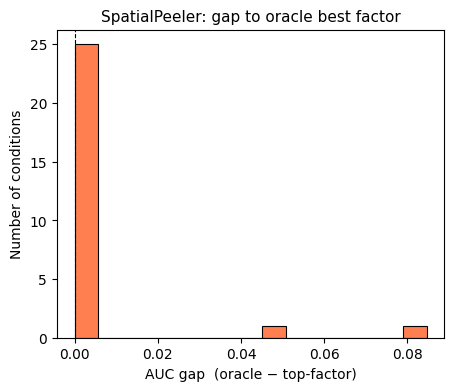

In [103]:
# Gap: how much does SpatialPeeler lose vs the oracle?
results_df['auc_gap'] = results_df['best_auc'] - results_df['top_auc']

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(results_df['auc_gap'], bins=15, color='coral', edgecolor='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('AUC gap  (oracle − top-factor)', fontsize=10)
ax.set_ylabel('Number of conditions', fontsize=10)
ax.set_title('SpatialPeeler: gap to oracle best factor', fontsize=11)

print(results_df['auc_gap'].describe().round(3))
print(f'Cases where gap = 0: {(results_df["auc_gap"] < 1e-6).sum()} / {len(results_df)}')


print(results_df['auc_gap'].describe().round(3))

print(f'Mean gap:   {results_df["auc_gap"].mean():.3f}')
print(f'Cases where top_auc == best_auc: '
      f'{(results_df["auc_gap"] < 1e-6).sum()} / {len(results_df)}')

#### 8. Gene-based evaluation: Jaccard index For each condition, Pearson correlation between the top factor's p_hat (on case beads) and all HVG gene expression vectors identifies the genes most associated with the spatial pattern.Taking the top-N correlated genes (N = number of perturbed genes for that condition) and comparing against the ground-truth perturbed gene set gives the Jaccard index.

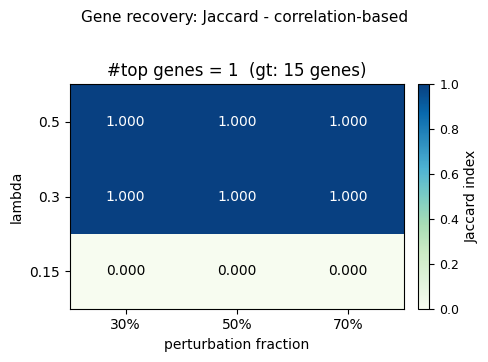

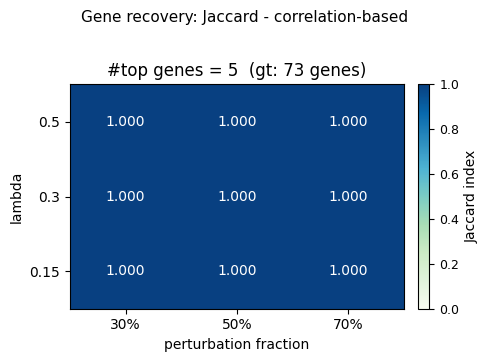

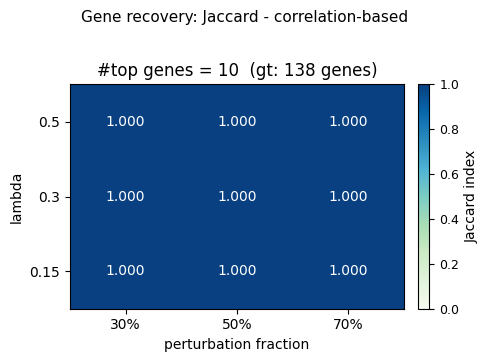

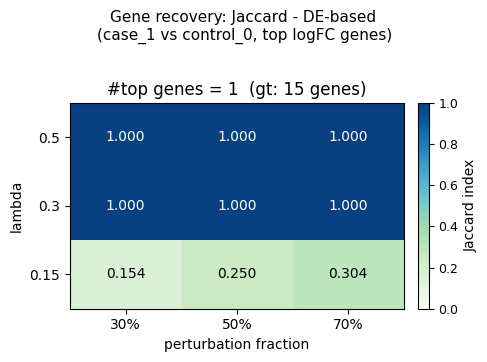

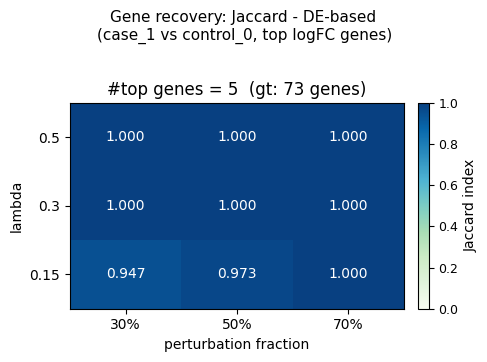

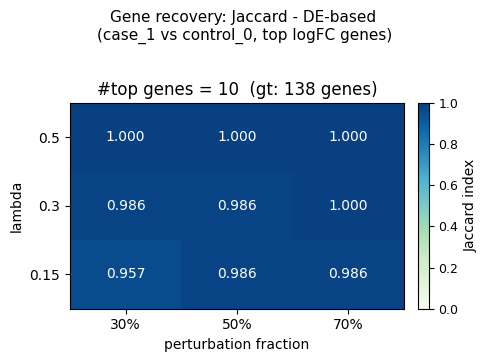

In [100]:
for metric, title in [
    ('gene_jaccard_all', 'Gene recovery: Jaccard - correlation-based'), #(all perturbed genes)
    #('gene_jaccard_hvg', 'Jaccard - correlation-based (HVG-surviving genes only)'),
    ('gene_jaccard_de',  'Gene recovery: Jaccard - DE-based \n(case_1 vs control_0, top logFC genes)'),
]:
    for tg in TOP_GENES_LIST:
        sub = results_df[results_df['top_genes'] == tg]
        mat = sub.pivot(index='fixed_lam', columns='perturb_frac', values=metric)
        mat = mat.sort_index(ascending=False)

        fig, ax = plt.subplots(figsize=(5, 3.5))
        im = ax.imshow(mat.values, cmap='GnBu', vmin=0, vmax=1, aspect='auto') #YlGn

        ax.set_xticks(range(len(mat.columns)))
        ax.set_xticklabels([f'{c:.0%}' for c in mat.columns], fontsize=10)
        ax.set_yticks(range(len(mat.index)))
        ax.set_yticklabels([str(r) for r in mat.index], fontsize=10)
        ax.set_xlabel('perturbation fraction', fontsize=10)
        ax.set_ylabel('lambda', fontsize=10)
        ax.set_title(f'#top genes = {tg}  (gt: {len(nmf_genes_by_tg[tg])} genes)', fontsize=12)

        for r_i, row in enumerate(mat.values):
            for c_i, val in enumerate(row):
                ax.text(c_i, r_i, f'{val:.3f}', ha='center', va='center',
                        fontsize=10, color='white' if val >= 0.5 else 'black')

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Jaccard index', fontsize=10)
        cbar.ax.tick_params(labelsize=9)

        fig.suptitle(title, fontsize=11, y=1.02)
        plt.tight_layout()
        plt.show()